# Pro player cohorts, part 5: the roster-aging curve

**Purpose**: a direct follow-up to the generational-cohort section of
`pro_player_debut_age_and_tenure.ipynb`. That notebook found the
cross-sectional "newer titles have younger rosters" pattern mostly
dissolves once you control for how long a title has existed --
explained mechanically as **aging in place**: a title's active roster
each year is a mix of fresh debutants and holdover veterans who simply
got one year older while staying active, and an older title has had
more years to accumulate that holdover mass.

**This notebook measures that mechanism directly, year by year, for
every title**, using one clean benchmark: if a title's roster were
*fully stagnant* (same people, zero effective rookie dilution), its
median active-player age would rise by exactly **+1.0 year every
calendar year**. The gap between a title's actual year-over-year median-
age change and that +1.0 benchmark is a direct read of how much real
rookie turnover is offsetting pure aging, each year, for each title --
called `delta` throughout. `delta = 1.0` -> fully stagnant.
`delta = 0.0` -> perfectly steady-state (rookies exactly offset aging).
`delta < 0` -> actively getting younger.

**Headline result to be shown in full below**: pooled across all 19
titles with usable data, `delta` is NOT a flat ~0.45 constant -- it has
a real shape, rising from near 0 (or negative) in a title's first
~4 years to near 1.0 (full stagnation) by ~13+ years since release.
Checked for whether that's a real within-title pattern or just a
cross-title pooling artifact (it's mostly real -- see the dedicated
check below).

Same scope as the rest of this thread: C0/C1/C2 only (C3 fighting games
excluded, no player data at all -- see part 1's intro for why).

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

from etl.db import get_connection

COMMUNITY_TITLE_LISTS = {
    "C0": ["apex_legends", "fortnite", "league_of_legends", "overwatch", "rainbow_six_siege", "rocket_league", "teamfight_tactics", "valorant"],
    "C1": ["age_of_empires_ii", "counter_strike", "dota2", "hearthstone", "pubg", "starcraft2"],
    "C2": ["brawl_stars", "free_fire", "mobile_legends_bb", "pubg_mobile", "wild_rift"],
    "C3": ["guilty_gear", "mortal_kombat", "street_fighter", "tekken"],
}
community_by_title = {t: c for c, titles in COMMUNITY_TITLE_LISTS.items() for t in titles}
in_scope_titles = [t for t in community_by_title if community_by_title[t] != "C3"]

import yaml
with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]
display_name_by_id = {t["id"]: t["display_name"] for t in titles_config if t.get("is_active")}

colors = {"C0": "#C44E52", "C1": "#4C72B0", "C2": "#55A868"}

# ACTUAL literal release year of the tracked/currently-competed build --
# same dict as pro_player_debut_age_and_tenure.ipynb's generational-cohort
# section, not FRANCHISE_YEAR (IP-origin year, a different variable used
# elsewhere in that same notebook for a different question).
ACTUAL_RELEASE_YEAR = {
    "age_of_empires_ii": 1999, "starcraft2": 2010, "counter_strike": 2012, "dota2": 2013,
    "hearthstone": 2014, "rocket_league": 2015, "rainbow_six_siege": 2015, "overwatch": 2016,
    "league_of_legends": 2009, "mobile_legends_bb": 2016, "pubg": 2017, "pubg_mobile": 2018,
    "free_fire": 2017, "fortnite": 2017, "brawl_stars": 2018, "apex_legends": 2019,
    "teamfight_tactics": 2019, "wild_rift": 2020, "valorant": 2020,
}

## Build the (title, active-year, age) table

Same validated join as `pro_player_debut_age_and_tenure.ipynb`
(`squadplayers_lpdb.player_link`, falling back to `player_id`, matched to
`players_lpdb.liquipedia_page` for `birthdate`) -- not re-derived
differently here. A player counts as active in year Y if any roster
stint spans it (`first_join <= Y-end` and `career_end >= Y-start`,
where `career_end` is today if any stint is still open).

In [2]:
conn = get_connection()
sp = pd.DataFrame(conn.execute(
    "SELECT title_id, player_link, player_id, join_date, leave_date FROM squadplayers_lpdb WHERE join_date IS NOT NULL"
).fetchall(), columns=["title_id", "player_link", "player_id", "join_date", "leave_date"])
players = pd.DataFrame(conn.execute(
    "SELECT title_id, liquipedia_page, birthdate FROM players_lpdb WHERE birthdate IS NOT NULL"
).fetchall(), columns=["title_id", "liquipedia_page", "birthdate"])
conn.close()

sp["join_date"] = pd.to_datetime(sp["join_date"], errors="coerce")
sp["leave_date"] = pd.to_datetime(sp["leave_date"], errors="coerce")
sp = sp[(sp["join_date"] >= "1998-01-01") & (sp["title_id"].isin(in_scope_titles))].reset_index(drop=True)
players["birthdate"] = pd.to_datetime(players["birthdate"], errors="coerce")

m = sp.merge(players.rename(columns={"liquipedia_page": "player_link"}), on=["title_id", "player_link"], how="left").reset_index(drop=True)
unmatched_mask = m["birthdate"].isna().reset_index(drop=True)
fb = m.loc[unmatched_mask, ["title_id", "player_id"]].merge(
    players.rename(columns={"liquipedia_page": "player_id", "birthdate": "bd2"}), on=["title_id", "player_id"], how="left")
m.loc[unmatched_mask, "birthdate"] = fb["bd2"].values
m = m.dropna(subset=["birthdate"])

span = m.groupby(["title_id", "player_link"]).agg(
    first_join=("join_date", "min"), last_leave=("leave_date", "max"),
    any_open=("leave_date", lambda s: s.isna().any()), birthdate=("birthdate", "first"),
).reset_index()
span["career_end"] = np.where(span["any_open"] | span["last_leave"].isna(), pd.Timestamp("2026-10-02"), span["last_leave"])
span["career_end"] = pd.to_datetime(span["career_end"])

YEARS_RANGE = range(2012, 2027)
active_rows = []
for _, r in span.iterrows():
    by = r["birthdate"].year
    for y in YEARS_RANGE:
        y_start, y_end = pd.Timestamp(f"{y}-01-01"), pd.Timestamp(f"{y}-12-31")
        if r["first_join"] <= y_end and r["career_end"] >= y_start:
            active_rows.append((r["title_id"], y, y - by))

active_age_df = pd.DataFrame(active_rows, columns=["title_id", "year", "age"])
active_age_df = active_age_df[(active_age_df["age"] >= 10) & (active_age_df["age"] <= 45)]
print(f"{len(active_age_df):,} (title, active-year, age) rows built across {active_age_df['title_id'].nunique()} titles")

135,457 (title, active-year, age) rows built across 19 titles


## Median active-player age, every title, every year -- the full table

In [3]:
med = active_age_df.groupby(["title_id", "year"]).agg(median_age=("age", "median"), n=("age", "size")).reset_index()
med = med[med["n"] >= 20].sort_values(["title_id", "year"])
med["prev_median"] = med.groupby("title_id")["median_age"].shift(1)
med["prev_year"] = med.groupby("title_id")["year"].shift(1)
med["delta"] = med["median_age"] - med["prev_median"]
deltas = med[med["year"] == med["prev_year"] + 1].copy()  # consecutive years only
deltas["community"] = deltas["title_id"].map(community_by_title)
deltas["release_year"] = deltas["title_id"].map(ACTUAL_RELEASE_YEAR)
deltas["years_since_release"] = deltas["year"] - deltas["release_year"]
deltas["title"] = deltas["title_id"].map(display_name_by_id)

print(f"{len(deltas)} (title, consecutive-year-pair) deltas, {deltas['title_id'].nunique()} titles")
deltas[["title", "community", "year", "n", "median_age", "delta", "years_since_release"]].to_string()

187 (title, consecutive-year-pair) deltas, 19 titles


'                            title community  year     n  median_age  delta  years_since_release\n1               Age of Empires II        C1  2013    89        24.0    1.0                   14\n2               Age of Empires II        C1  2014   107        24.0    0.0                   15\n3               Age of Empires II        C1  2015   122        25.0    1.0                   16\n4               Age of Empires II        C1  2016   130        26.0    1.0                   17\n5               Age of Empires II        C1  2017   146        26.0    0.0                   18\n6               Age of Empires II        C1  2018   165        27.0    1.0                   19\n7               Age of Empires II        C1  2019   192        28.0    1.0                   20\n8               Age of Empires II        C1  2020   210        28.0    0.0                   21\n9               Age of Empires II        C1  2021   237        28.0    0.0                   22\n10              Age of Empire

## Chart 1: median active-player age trajectory, every title, calendar time

Small multiples, one panel per title -- the fully-stagnant +1/year
benchmark drawn as a faint dashed reference line from each title's own
first plotted point, so a title's own curve can be read directly
against it.

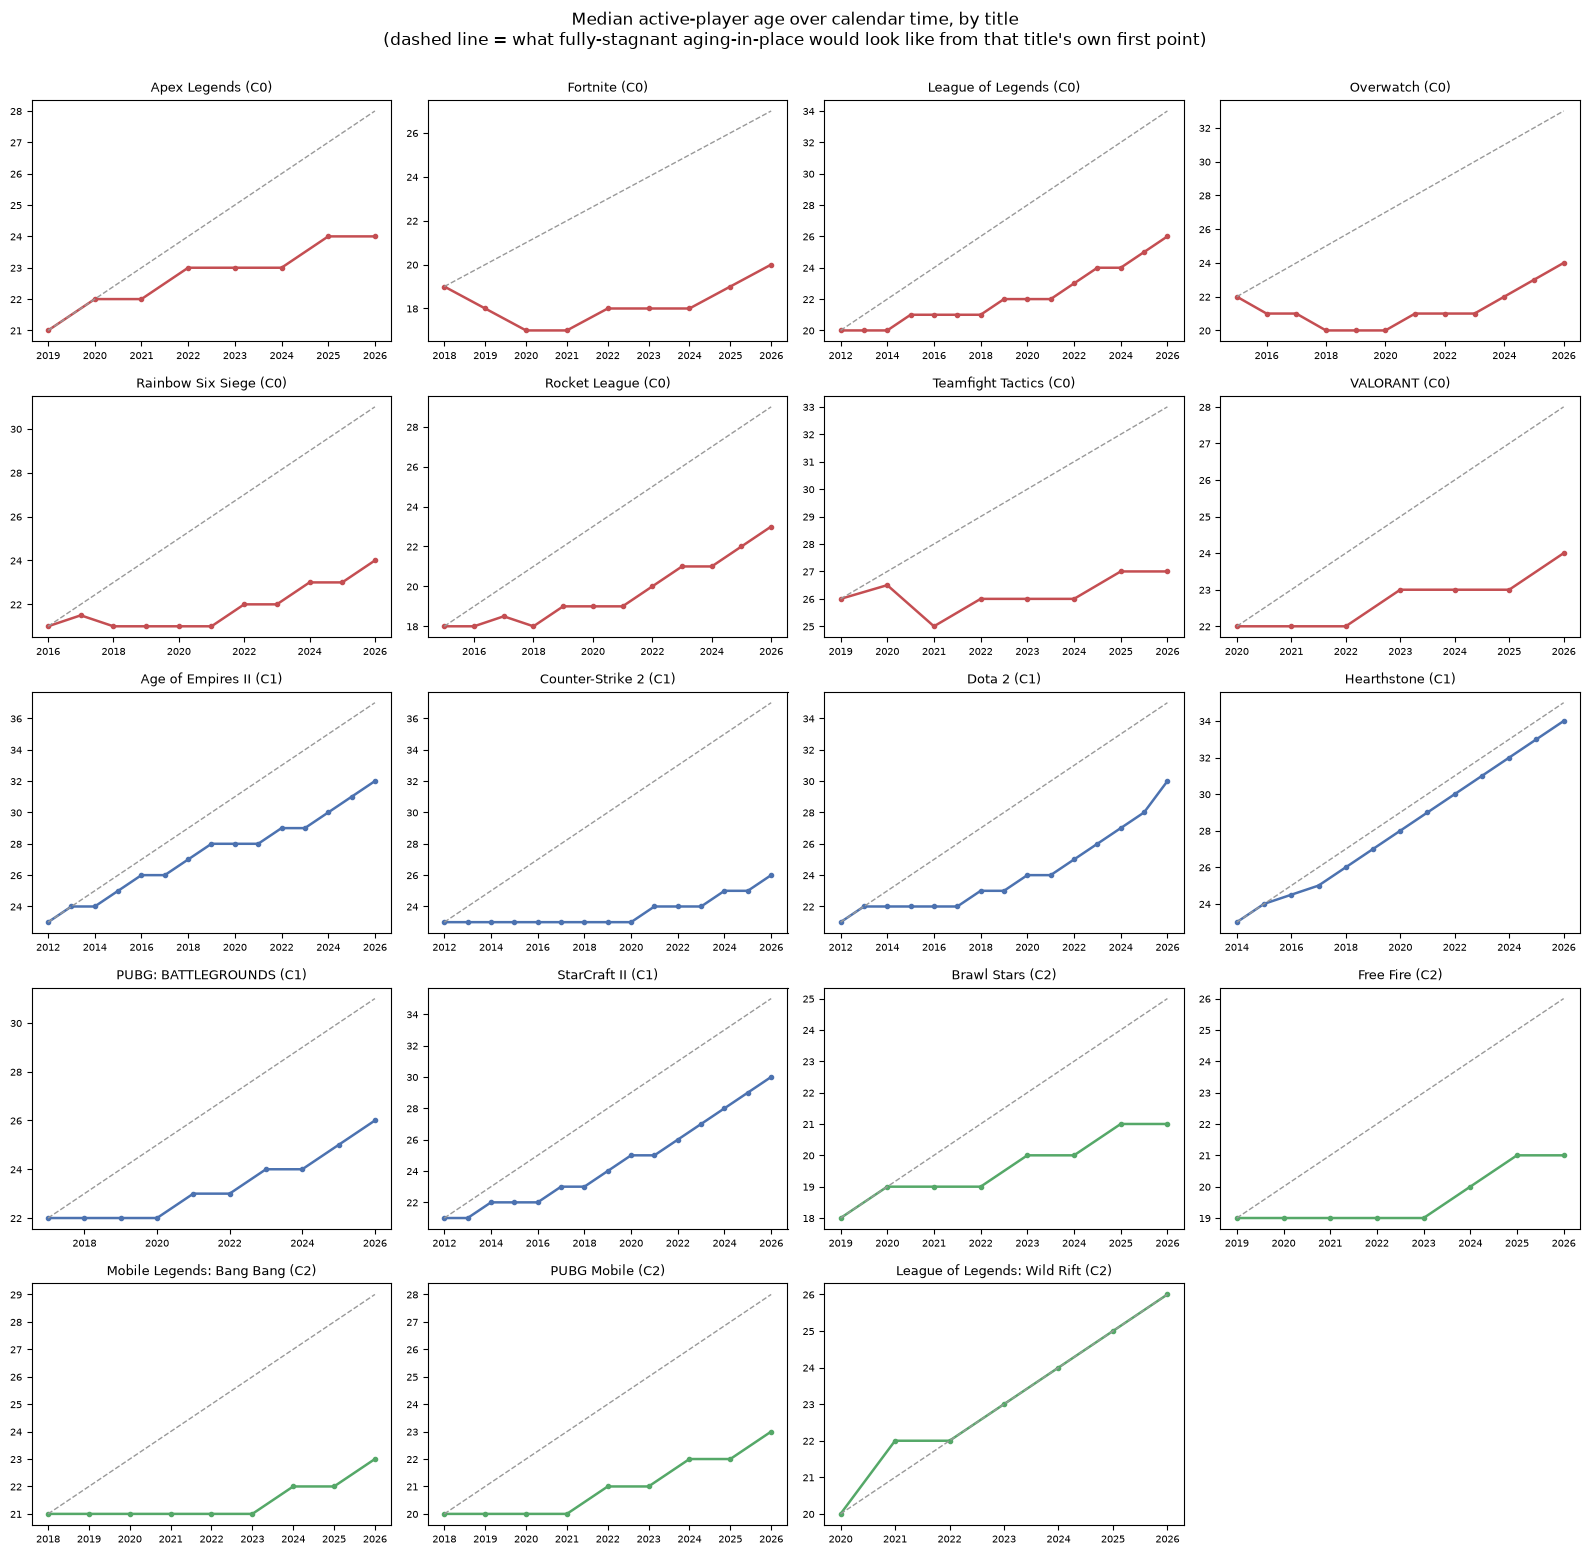

In [4]:
titles_sorted = sorted(med["title_id"].unique(), key=lambda t: community_by_title[t])
n = len(titles_sorted)
ncols = 4
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.1 * nrows), sharey=False)
axes = axes.flatten()

for i, t in enumerate(titles_sorted):
    ax = axes[i]
    sub = med[med["title_id"] == t].sort_values("year")
    c = community_by_title[t]
    ax.plot(sub["year"], sub["median_age"], color=colors[c], marker="o", markersize=3, linewidth=1.8)
    if len(sub) >= 2:
        y0, x0 = sub["median_age"].iloc[0], sub["year"].iloc[0]
        xs = sub["year"].values
        ax.plot(xs, y0 + (xs - x0), color="#999", linestyle="--", linewidth=1, label="fully stagnant (+1/yr)")
    ax.set_title(f"{display_name_by_id[t]} ({c})", fontsize=9.5)
    ax.tick_params(labelsize=7.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Median active-player age over calendar time, by title\n(dashed line = what fully-stagnant aging-in-place would look like from that title's own first point)", y=1.0, fontsize=12)
plt.tight_layout()
plt.savefig(Path.cwd() / "_roster_aging_fig1_small_multiples.png", dpi=150, bbox_inches="tight")
plt.show()

### Read -- small multiples

**Visually confirmed against the rendered chart (not just the numbers):
two real but distinct shapes among the legacy titles, not one uniform
story.** Counter-Strike 2, Dota 2, StarCraft II, and League of Legends
all show a genuine bend -- flat or near-flat for their first several
years (well below the dashed stagnant line), then visibly steepening in
their later years to approach or nearly meet it. That's real early
rejuvenation fading over time, matching their positive within-title
correlations below. **Hearthstone and Age of Empires II don't show that
bend at all -- they track close to the dashed stagnant line almost from
their very first plotted point**, not converging toward it so much as
never having had much of a gap to begin with. This matches Age of
Empires II's near-zero within-title correlation (r=0.092) in the
robustness check below, and explains why Hearthstone's own r, while
positive, isn't as central to the story as the bend seen in CS2/Dota2/
StarCraft II/LoL.

**Nearly every younger title sits visibly below its own dashed line for
most of its plotted history** -- Fortnite and Overwatch both show a
real dip-then-recover shape (Fortnite: ~19 in 2018 down to 17 by 2020,
back up to 20 by 2026), consistent with real, sustained rejuvenation,
not just a flat launch-year blip. VALORANT, Apex Legends, Rainbow Six
Siege, Rocket League, Teamfight Tactics, Brawl Stars, Free Fire, Mobile
Legends, and PUBG Mobile all show the same qualitative pattern: actual
curve well below the stagnant-benchmark line throughout. **Wild Rift is
the one clear exception among the younger titles** -- its curve tracks
close to or even briefly above its own dashed line, consistent with its
outlier mean delta (1.00) noted earlier, though on a thin sample (6
year-pairs) that's worth treating cautiously rather than as a real
exception to the broader pattern.

## Chart 2: the aging curve itself -- delta vs. years since release, pooled

Pooled: years_since_release vs delta -- Pearson r=0.325 (p=0.000006), Spearman rho=0.375 (p=0.000000), n=187


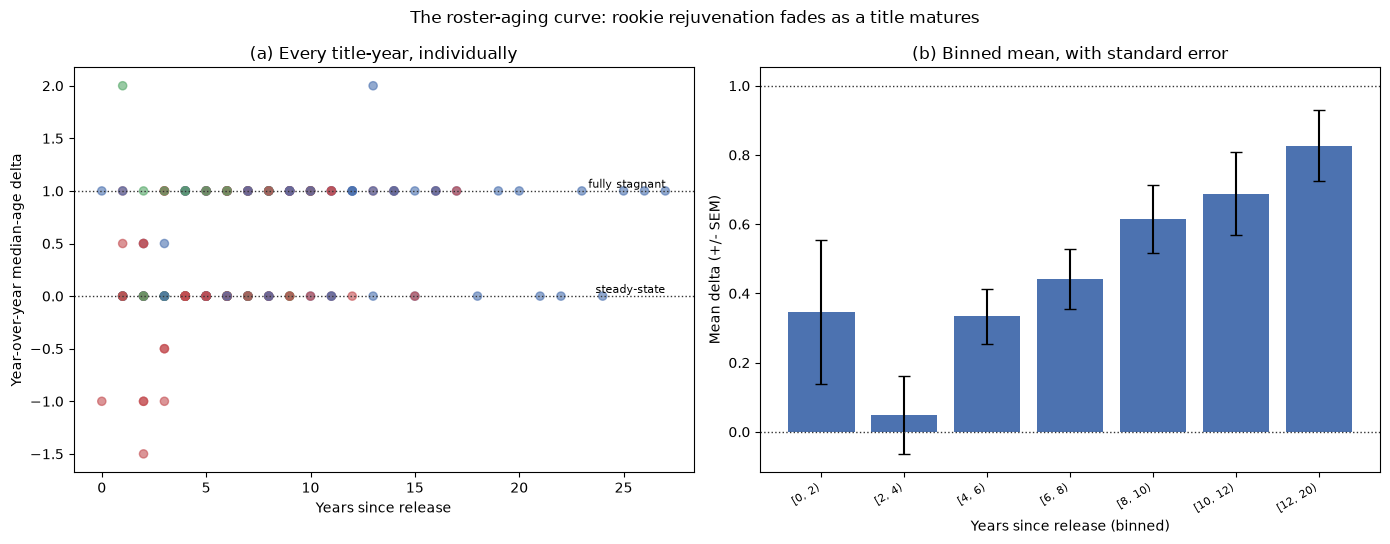

,ysr_bin,mean_delta,sem,n
0,"[0, 2)",0.346,0.207,13
1,"[2, 4)",0.048,0.112,31
2,"[4, 6)",0.333,0.080,36
3,"[6, 8)",0.441,0.086,34
4,"[8, 10)",0.615,0.097,26
5,"[10, 12)",0.688,0.120,16
6,"[12, 20)",0.826,0.102,23


In [5]:
r, p = pearsonr(deltas["years_since_release"], deltas["delta"])
rho, ps = spearmanr(deltas["years_since_release"], deltas["delta"])
print(f"Pooled: years_since_release vs delta -- Pearson r={r:.3f} (p={p:.6f}), Spearman rho={rho:.3f} (p={ps:.6f}), n={len(deltas)}")

bins = [0, 2, 4, 6, 8, 10, 12, 20]
deltas["ysr_bin"] = pd.cut(deltas["years_since_release"], bins, right=False)
binned = deltas.groupby("ysr_bin", observed=True).agg(mean_delta=("delta", "mean"), sem=("delta", lambda s: s.std() / np.sqrt(len(s))), n=("delta", "size")).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

ax1.scatter(deltas["years_since_release"], deltas["delta"], c=[colors[c] for c in deltas["community"]], alpha=0.6, s=35)
ax1.axhline(1.0, color="#333", linestyle=":", linewidth=1)
ax1.axhline(0.0, color="#333", linestyle=":", linewidth=1)
ax1.text(deltas["years_since_release"].max(), 1.03, "fully stagnant", fontsize=8, ha="right")
ax1.text(deltas["years_since_release"].max(), 0.03, "steady-state", fontsize=8, ha="right")
ax1.set_xlabel("Years since release")
ax1.set_ylabel("Year-over-year median-age delta")
ax1.set_title("(a) Every title-year, individually")

x_pos = range(len(binned))
ax2.bar(x_pos, binned["mean_delta"], yerr=binned["sem"], color="#4C72B0", capsize=4)
ax2.axhline(1.0, color="#333", linestyle=":", linewidth=1)
ax2.axhline(0.0, color="#333", linestyle=":", linewidth=1)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([str(b) for b in binned["ysr_bin"]], rotation=30, ha="right", fontsize=8)
ax2.set_xlabel("Years since release (binned)")
ax2.set_ylabel("Mean delta (+/- SEM)")
ax2.set_title("(b) Binned mean, with standard error")

fig.suptitle("The roster-aging curve: rookie rejuvenation fades as a title matures")
plt.tight_layout()
plt.savefig(Path.cwd() / "_roster_aging_fig2_curve.png", dpi=150, bbox_inches="tight")
plt.show()
binned.round(3)

## Robustness check: is this a real within-title pattern, or a cross-title pooling artifact?

The pooled regression above could in principle be driven entirely by
*which* titles happen to dominate the late-years_since_release bins
(only the oldest titles can appear there at all), rather than by any
individual title actually following this curve itself. Checked directly:
for every title with >=10 years of its own delta history, does *its own*
delta trend upward with *its own* years_since_release?

In [6]:
within_rows = []
for t in deltas["title_id"].unique():
    sub = deltas[deltas["title_id"] == t]
    if len(sub) < 10:
        continue
    r, p = pearsonr(sub["years_since_release"], sub["delta"])
    within_rows.append({"title": display_name_by_id[t], "community": community_by_title[t], "n_years": len(sub), "within_title_r": round(r, 3), "p": round(p, 4)})
pd.DataFrame(within_rows).sort_values("within_title_r", ascending=False)

,title,community,n_years,within_title_r,p
5,Overwatch,C0,11,0.803,0.0029
2,Dota 2,C1,14,0.624,0.0170
1,Counter-Strike 2,C1,14,0.540,0.0463
8,StarCraft II,C1,14,0.536,0.0481
3,Hearthstone,C1,12,0.518,0.0844
7,Rocket League,C0,11,0.504,0.1138
6,Rainbow Six Siege,C0,10,0.478,0.1624
4,League of Legends,C0,14,0.465,0.0935
0,Age of Empires II,C1,14,0.092,0.7533


### Read -- the aging curve is real, significant, and mostly survives a within-title check

**Pooled relationship is clear and highly significant**: years-since-
release vs. delta, Pearson r=0.325 (p=0.000006), Spearman rho=0.375
(p<0.000001), n=187 title-years. Binned, the climb is close to
monotonic: 0.35 in years 0-2, dropping to 0.05 in years 2-4 (the single
lowest bin -- the point of maximum rejuvenation across the whole
dataset), then climbing steadily through 0.33, 0.44, 0.62, 0.69, to
0.83 by 12-20 years since release -- from "actively getting younger" to
"within spitting distance of fully stagnant."

**This is not just a pooling artifact of which titles happen to sit in
which bin -- it mostly replicates within individual long-running
titles too.** Of the 9 titles with >=10 years of their own delta
history: Overwatch shows the strongest individual trend (r=0.803,
p=0.0029), followed by Dota 2 (r=0.624, p=0.0170), Counter-Strike 2
(r=0.540, p=0.0463), and StarCraft II (r=0.536, p=0.0481) -- all
individually significant. Hearthstone (r=0.518, p=0.0844), Rocket
League (r=0.504, p=0.114), Rainbow Six Siege (r=0.478, p=0.162), and
League of Legends (r=0.465, p=0.094) all point the same direction but
don't individually clear significance on 10-14 data points each --
consistent with a real effect that's underpowered at the single-title
level, the same pattern seen for the launch-cohort-age finding earlier
in this thread. **Age of Empires II is the one genuine exception**
(r=0.092, p=0.753, no relationship) -- and the small-multiples chart
shows why: unlike the other legacy titles, it never had much of a
rejuvenation gap to close in the first place, tracking close to the
fully-stagnant benchmark almost from its earliest plotted year.

**Net: the roster-aging curve is a real, replicated phenomenon, not an
artifact of pooling different titles into different maturity bins.**
A title's rookie pipeline measurably loses ground to aging-in-place as
the title matures -- fastest in the first 2-4 years (when delta is at
its most negative/lowest), then climbing toward full stagnation by
roughly a decade in. This reframes the earlier "mean delta ~0.45"
finding: that number isn't a stable property of esports rosters in
general, it's an average taken across titles at very different points
along one real, shared maturation curve.

## Caveats

- **C3 excluded entirely** -- no player data, same as every other
  notebook in this thread.
- **The oldest `years_since_release` bins are dominated by a handful of
  legacy titles** (Counter-Strike, Dota 2, StarCraft II, Age of Empires
  II, Hearthstone, League of Legends are the only titles with 10+ years
  of tracked delta history) -- the late end of the pooled curve is
  really describing those specific titles, not a broad sample. The
  within-title check above is what actually establishes this isn't just
  those titles' own idiosyncrasies pooled together, but it's still a
  small set of titles carrying the tail of the curve.
- **`median_age` is computed from calendar year minus birth year, not
  exact fractional age** -- this is why deltas land on values like 0.5
  rather than only whole numbers (a median of two adjacent integer ages).
  Coarse but consistent across every title, not a source of bias in the
  comparison.
- **A player whose LPDB page is stale (never updated to "Retired")
  stays counted as active indefinitely in this method** -- same
  limitation as every other notebook in this thread that uses
  `career_end = today if any stint lacks a leave_date`. Affects recent
  years more than old ones (less time for a stale page to be noticed and
  corrected), and would bias delta *toward* stagnation in recent years,
  not away from it -- so it doesn't explain away the aging-curve finding,
  if anything it's a conservative bias in the same direction as what's
  already being found for mature titles.